## Genomics

Leukemia is a cancer of blood-generating tissues. Over 475,000 Americans have Leukemia or are in remission from it. It accounts for 3.3% of all new cancer cases and 3.8% of cancer deaths, with an estimated 66,890 new cases and 23,540 deaths in the U.S. in 2025.

There are two major leukemia families: Acute Lymphoblastic Leukemia (ALLB and ALLT, or ALL), which is cancer of immature lymphoid cells, and Acute Myeloid Leukemia (AML), which is cancer of cancer of immature myeloid cells.

Golub et al. (*Science*, 1999) popularized a dataset including about 7000 genes from 72 patients. The goal is to use genomics data to predict which patients are at risk of ALL versus AML, because the distinction is critical for timely and effective treatment.

1. Load the `golub.csv` dataset. Relabel all instances of ALLB and ALLT as 0, and all instances of ALL as 1. This is the target variable. 

2. Use Linear Regression of the target variable on all of the genes provided. What is your mean squared error? Make a kernel density plot of your residuals, and a scatter plot comparing predicted and actual outcomes. 

3. Use cross validation to compute the mean squared error of the linear model. Discuss your results from the perspective of the bias variance trade-off.

4. Use the cross validated LASSO to select a set of highly predictive genes. Which set of genes is selected? How many genes are discarded from the model? Make a scatterplot of your predictions versus the actual values. 

5. Make a plot that shows the cross validated MSE as $alpha$ varies. For what values of $\alpha$ is the LASSO underfitting? Overfitting? What is the optimal penality hyperparameter that minimizes expected MSE?

6. Explain why linear regression performs perfectly on the training set, but the LASSO provides better predictions overall.

7. Why do regularization methods lend themselves to scenarios like precision health? 

8. What are the risks of applying methods like the Lasso to precision health questions, where interventions will then be taken to optimize patient health?

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression, LassoCV, Lasso
from sklearn.preprocessing import StandardScaler

mse = lambda y_true, y_pred: np.mean((y_true - y_pred) ** 2)

In [61]:
# Load the `golub.csv` dataset. Relabel all instances of ALLB and ALLT as 0, and 
# all instances of ALL as 1. This is the target variable.

df = pd.read_csv('./data/golub.csv')
df.head()

,Samples,BM.PB,Gender,Source,tissue.mf,cancer,AFFX-BioB-5_at,AFFX-BioB-M_at,AFFX-BioB-3_at,AFFX-BioC-5_at,...,U48730_at,U58516_at,U73738_at,X06956_at,X16699_at,X83863_at,Z17240_at,L49218_f_at,M71243_f_at,Z78285_f_at
0,39,BM,F,DFCI,BM:f,allB,-1363.276427,-1058.585495,-541.469194,74.349803,...,-35.081447,1565.618803,-485.680714,-170.261227,-919.114293,1675.050053,389.769289,-526.449219,-268.963924,-779.643092
1,40,BM,F,DFCI,BM:f,allB,-796.285053,-1167.103365,7.538493,83.544731,...,-404.737767,622.498054,-1275.354673,214.828233,-750.220666,-441.589276,9.841713,-671.911209,-671.911209,-644.272577
2,42,BM,F,DFCI,BM:f,allB,-679.139168,-1069.832308,-690.301829,-112.075981,...,193.780934,162.525483,-692.534361,517.498108,-674.674103,1265.396405,-65.192805,-714.859684,3672.066149,-822.021231
3,47,BM,M,DFCI,BM:m,allB,-1164.400197,-1109.939891,-990.127218,-238.574994,...,-256.002292,-31.625831,-621.975549,-458.594630,-630.689198,937.767618,-264.715941,-635.046022,475.944222,-794.070116
4,48,BM,F,DFCI,BM:f,allB,-1299.653758,-1401.998536,-1077.543813,-437.344560,...,-509.203660,383.591216,-905.517483,-36.675640,-1116.739685,316.087213,-210.879518,-953.423549,-291.448812,-1057.945876


In [62]:
mapping = {'allB': 0, 'allT': 0, 'aml': 1}
df['outcome'] = df['cancer'].map(mapping)
df.head()

,Samples,BM.PB,Gender,Source,tissue.mf,cancer,AFFX-BioB-5_at,AFFX-BioB-M_at,AFFX-BioB-3_at,AFFX-BioC-5_at,...,U58516_at,U73738_at,X06956_at,X16699_at,X83863_at,Z17240_at,L49218_f_at,M71243_f_at,Z78285_f_at,outcome
0,39,BM,F,DFCI,BM:f,allB,-1363.276427,-1058.585495,-541.469194,74.349803,...,1565.618803,-485.680714,-170.261227,-919.114293,1675.050053,389.769289,-526.449219,-268.963924,-779.643092,0
1,40,BM,F,DFCI,BM:f,allB,-796.285053,-1167.103365,7.538493,83.544731,...,622.498054,-1275.354673,214.828233,-750.220666,-441.589276,9.841713,-671.911209,-671.911209,-644.272577,0
2,42,BM,F,DFCI,BM:f,allB,-679.139168,-1069.832308,-690.301829,-112.075981,...,162.525483,-692.534361,517.498108,-674.674103,1265.396405,-65.192805,-714.859684,3672.066149,-822.021231,0
3,47,BM,M,DFCI,BM:m,allB,-1164.400197,-1109.939891,-990.127218,-238.574994,...,-31.625831,-621.975549,-458.594630,-630.689198,937.767618,-264.715941,-635.046022,475.944222,-794.070116,0
4,48,BM,F,DFCI,BM:f,allB,-1299.653758,-1401.998536,-1077.543813,-437.344560,...,383.591216,-905.517483,-36.675640,-1116.739685,316.087213,-210.879518,-953.423549,-291.448812,-1057.945876,0


In [63]:
y = df['outcome']
x = df.drop(['Samples', 'BM.PB', 'Gender', 'Source', 'tissue.mf', 'cancer', 'outcome'], axis = 1)

print('Number of Observations:', x.shape[0])
print('Number of Genes used as predictors:', x.shape[1])

Number of Observations: 72
Number of Genes used as predictors: 7129


In [64]:
# Use Linear Regression of the target variable on all of the genes provided. 
# What is your mean squared error? Make a kernel density plot of your residuals, 
# and a scatter plot comparing predicted and actual outcomes. 

ols = LinearRegression().fit(x,y)
y_hat = ols.predict(x)
res_ols = y_hat - y

print(f'OLS training MSE: {mse(y, y_hat):.6g}')

OLS training MSE: 1.6801e-30


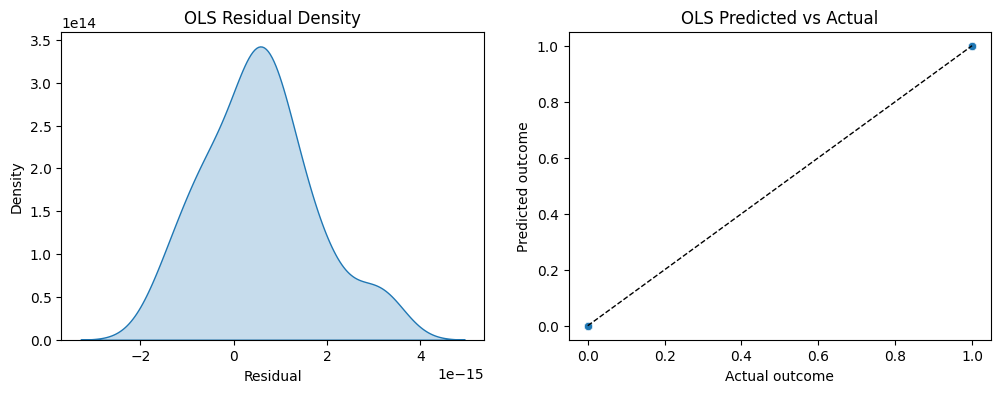

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.kdeplot(res_ols, fill=True, ax=axes[0])
axes[0].set_title('OLS Residual Density')
axes[0].set_xlabel('Residual')

sns.scatterplot(x=y, y=y_hat, ax=axes[1])
axes[1].plot([0, 1], [0, 1], linestyle='--', color='black', linewidth=1)
axes[1].set_title('OLS Predicted vs Actual')
axes[1].set_xlabel('Actual outcome')
axes[1].set_ylabel('Predicted outcome')

plt.show()

In [66]:
# Use cross validation to compute the mean squared error 
# of the linear model. Discuss your results from the 
# perspective of the bias variance trade-off.

kfold = KFold(n_splits = 5, shuffle=True, random_state = 100)

scores = cross_val_score(LinearRegression(), x, y, cv=kfold, scoring='neg_mean_squared_error')
cv_mse = -scores

print('KFold MSE:', cv_mse)
print('Mean KFold MSE:', cv_mse.mean())
print('Median KFold MSE:', np.median(cv_mse))
print('St Dev Kfold MSE:', cv_mse.std())

KFold MSE: [0.0244198  0.05792023 0.09224999 0.02097934 0.02126042]
Mean KFold MSE: 0.04336595898622783
Median KFold MSE: 0.02441980379753735
St Dev Kfold MSE: 0.028107820694269883


From this information, we are able to tell that the MSE from the KFold Cross Validation is far larger than that of the training data. This tells us that there is high variance. Although it seemed like the training model was a great fit, it seems as though it is not a great fit beyond that. The bias is still low, but since there are so many genes for the far smaller number of patients that we are looking at, the variance is high.

In [67]:
# Use the cross validated LASSO to select a set of 
# highly predictive genes. Which set of genes is selected? 
# How many genes are discarded from the model? 
# Make a scatterplot of your predictions versus the actual values. 

scaler = StandardScaler()
x_sc = scaler.fit_transform(x)

alpha_grid = np.logspace(-4, -2, num=50)
lasso_cv = LassoCV(cv=10, alphas=alpha_grid, random_state=100, max_iter=10000)
lasso_cv.fit(x_sc, y)

alpha_star = lasso_cv.alpha_
mean_mse_path = np.mean(lasso_cv.mse_path_, axis=1)
index_star = np.argmin(mean_mse_path)

coefs = []
for alpha in lasso_cv.alphas_:
    model = Lasso(alpha=alpha, max_iter=10000)
    model.fit(x_sc, y)
    coefs.append(model.coef_)
coefs = np.array(coefs)

coefs_star = coefs[index_star]
selected_idx = np.nonzero(coefs_star)[0]
selected_genes = x.columns[selected_idx].tolist()

lasso_star = Lasso(alpha=alpha_star, max_iter=10000).fit(x_sc, y)
y_hat_lasso = lasso_star.predict(x_sc)

print('opt. alpha:', alpha_star)
print('selected genes:', len(selected_genes))
print('discarded genes:', x.shape[1] - len(selected_genes))

opt. alpha: 0.0016768329368110067
selected genes: 70
discarded genes: 7059


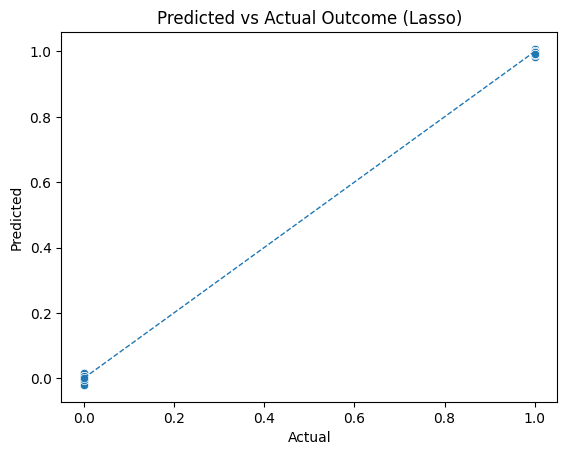

Lasso training MSE 4.642794416477649e-05


In [68]:
sns.scatterplot(x= y, y = y_hat_lasso)
plt.plot([0,1], [0,1], linestyle = '--', linewidth=1)
plt.title("Predicted vs Actual Outcome (Lasso)")
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

print('Lasso training MSE', mse(y, y_hat_lasso))

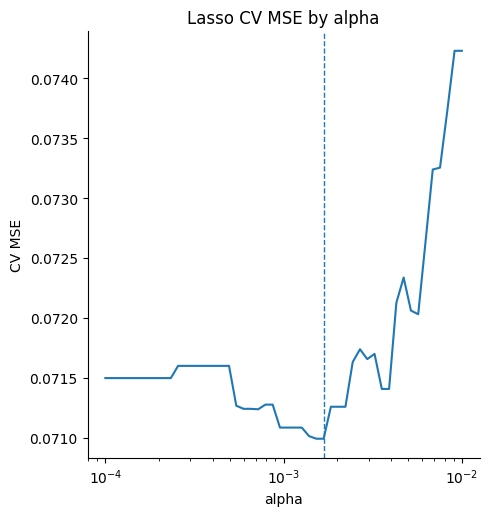

In [69]:
# Make a plot that shows the cross validated MSE as 
# $alpha$ varies. For what values of $\alpha$ is the LASSO 
# underfitting? Overfitting? What is the optimal penality 
# hyperparameter that minimizes expected MSE?

sns.relplot(kind='line', x = lasso_cv.alphas_, y = mean_mse_path)
plt.axvline(alpha_star, linestyle='--', linewidth = 1)
plt.title('Lasso CV MSE by alpha')
plt.ylabel('CV MSE')
plt.xlabel('alpha')
plt.xscale('log')
plt.show()

Everything to the left side of the plot is being underfit by the model while the values on the right of the line are overfit. The minimum expected error is at around 0.0016768329368110067.

*Explain why linear regression performs perfectly on the training set, but the LASSO provides better predictions overall.*  

Since ols has many more predictors than patients that it is looking at, it makes the coefficients more sensitive to more data coming in. Lasso has better predictions because it takes those coefficients and increases the bias while decreasing the variance, allowing the dataset to reach more of an equilibrium for the bias-variance tradeoff than before.  

*Why do regularization methods lend themselves to scenarios like precision health?*

It is very difficult to do this kind of testing and analyzing with huge datasets, so Lasso allows us to narrow our scope to only look at the more focused variables and values of a larger dataset and see how certain variables interact. This is better for this kind of testing because these interactions and relationships are important, so they want the most accurate data without being overwhelmed by the tests/findings.

*What are the risks of applying methods like the Lasso to precision health questions, where interventions will then be taken to optimize patient health?*

One of the main risks is that it provided predictions, and while we can calculate to see how accurate it is compared to the actual data, there is still room for error. Due to this, it is still fine that people are running studies to try to determine relationships to then optimize a patient's health, but since they are predictions and only correlational data, it is best to keep the risks of life-changing situations to a minimum if solely based on this data. 